# Market Modeling and System Operation

This notebook adapts [PyPSA](https://pypsa.org)'s official example notebook for market modelling [`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/) to Zambia.

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pypsa
import logging
import networkx as nx
logging.getLogger("pypsa.contingency").setLevel(logging.ERROR)


## 1. Market Modeling

This section reproduces PyPSA's
[`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/) example,
with the two market zones renamed **Copperbelt** and **Lusaka**, Zambia's two main demand
centres.

In [2]:
plt.style.use("bmh")
supply_bids = {
    "qty": [120, 100, 50, 60, 70, 60, 50],
    "price": [5, 15, 20, 36, 60, 150, 200],
}

demand_bids = {
    "qty": [250, 80, 20, 40, 60],
    "price": [200, 90, 75, 65, 24],
}

In [3]:
def clearing_point(supply_qty, supply_price, demand_qty, demand_price):
    """Quantity and price where the merit-order supply and demand curves cross."""
    s_cum = np.cumsum(supply_qty)
    d_cum = np.cumsum(demand_qty)
    q_max = int(min(s_cum[-1], d_cum[-1]))
    price, qty = supply_price[0], 0
    for q in range(1, q_max + 1):
        s_p = supply_price[np.searchsorted(s_cum, q)]
        d_p = demand_price[np.searchsorted(d_cum, q)]
        if s_p > d_p:
            break
        price, qty = s_p, q
    return qty, price

### Single market zone

First, we treat the whole country as a single .

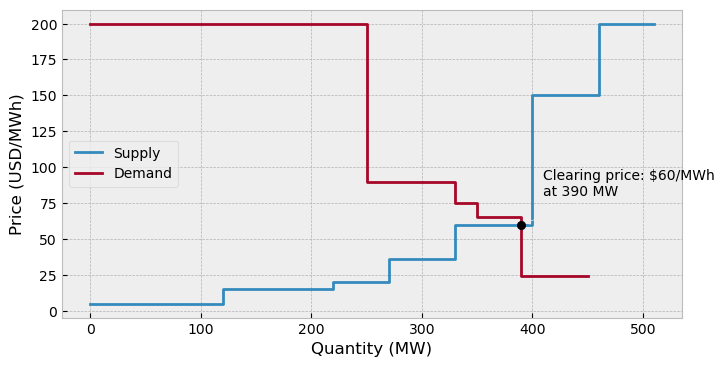

In [4]:
qty, price = clearing_point(
    supply_bids["qty"], supply_bids["price"], demand_bids["qty"], demand_bids["price"]
)

plt.figure(figsize=(8, 4))
plt.step(
    np.cumsum([0] + supply_bids["qty"]),
    supply_bids["price"][:1] + supply_bids["price"],
    label="Supply",
)
plt.step(
    np.cumsum([0] + demand_bids["qty"]),
    demand_bids["price"][:1] + demand_bids["price"],
    label="Demand",
)
plt.scatter([qty], [price], color="k", zorder=5)
plt.annotate(
    f"Clearing price: ${price}/MWh\nat {qty} MW",
    xy=(qty, price),
    xytext=(qty + 20, price + 20),
    arrowprops={"arrowstyle": "->"},
)
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()

PyPSA

In [5]:
n = pypsa.Network()
n.add("Bus", "Zambia")

# Add supply bids
n.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus="Zambia",
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)

# Add demand bids
n.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus="Zambia",
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [6]:
n.optimize(solver_name="highs")

Index(['Zambia'], dtype='object', name='Bus')
Index(['Zambia'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 25 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-va7e33um has 25 rows; 12 cols; 36 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [5e+00, 2e+02]
  Bound  [0e+00, 0e+00]
  RHS    [2e+01, 2e+02]
Presolving model
1 rows, 12 cols, 12 nonzeros  0s
Dependent equations search running on 1 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1 rows, 11 cols, 11 nonzeros  0s
Presolve : Reductions: rows 1(-24); columns 11(-1); elements 11(-25)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
          1    -5.2440000000e+04 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-va7e33um
Model status        : Optimal
Simplex   iterations: 1
Objective value     : -5.2440000000e+04
P-D obje

('ok', 'optimal')

The market-clearing objective, and the nodal balance constraint the Market Operator has to satisfy:

In [7]:
display(n.model.objective)
n.model.constraints["Bus-nodal_balance"]

Objective:
----------
LinearExpression: +5 Generator-p[now, supply_0] + 15 Generator-p[now, supply_1] + 20 Generator-p[now, supply_2] ... -75 Generator-p[now, demand_2] - 65 Generator-p[now, demand_3] - 24 Generator-p[now, demand_4]
Sense: min
Value: -52440.0

Constraint `Bus-nodal_balance` [Bus: 1, snapshot: 1]:
-----------------------------------------------------
[Zambia, now]: +1 Generator-p[now, supply_0] + 1 Generator-p[now, supply_1] + 1 Generator-p[now, supply_2] ... -1 Generator-p[now, demand_2] - 1 Generator-p[now, demand_3] - 1 Generator-p[now, demand_4] = -0.0

In [8]:
display(n.model.constraints["Generator-fix-p-upper"])
display(n.model.constraints["Generator-fix-p-lower"])

Constraint `Generator-fix-p-upper` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≤ 120.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≤ 100.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≤ 50.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≤ 60.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≤ 70.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≤ 60.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≤ 50.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≤ 250.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≤ 80.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≤ 20.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≤ 40.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≤ 60.0

Constraint `Generator-fix-p-lower` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≥ -0.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≥ -0.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≥ -0.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≥ -0.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≥ -0.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≥ -0.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≥ -0.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≥ -0.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≥ -0.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≥ -0.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≥ -0.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≥ -0.0

The single, uniform clearing price for the whole country, and the resulting dispatch:

In [9]:
n.buses_t.marginal_price

Bus,Zambia
snapshot,
now,60.0


In [10]:
n.generators_t.p

Generator,supply_0,supply_1,supply_2,supply_3,supply_4,supply_5,supply_6,demand_0,demand_1,demand_2,demand_3,demand_4
snapshot,,,,,,,,,,,,
now,120.0,100.0,50.0,60.0,60.0,-0.0,-0.0,250.0,80.0,20.0,40.0,-0.0


### Two zones: Copperbelt and Lusaka

Now we split supply and demand between the **Copperbelt** and **Lusaka**

In [11]:
supply_bids["zone"] = ["Lusaka", "Copperbelt", "Lusaka", "Copperbelt", "Copperbelt", "Copperbelt", "Copperbelt"]
demand_bids["zone"] = ["Copperbelt", "Lusaka", "Lusaka", "Copperbelt", "Lusaka"]

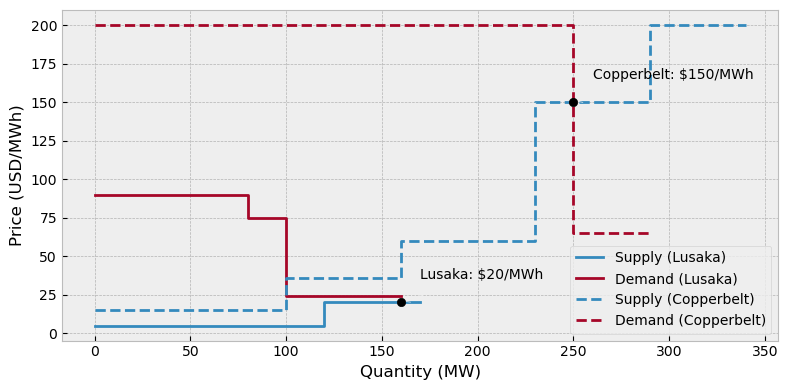

In [12]:
plt.figure(figsize=(8, 4))

for zone, linestyle in zip(["Lusaka", "Copperbelt", ], ["-", "--"]):
    s_idx = [i for i, z in enumerate(supply_bids["zone"]) if z == zone]
    d_idx = [i for i, z in enumerate(demand_bids["zone"]) if z == zone]

    s_qty = [supply_bids["qty"][i] for i in s_idx]
    s_price = [supply_bids["price"][i] for i in s_idx]
    d_qty = [demand_bids["qty"][i] for i in d_idx]
    d_price = [demand_bids["price"][i] for i in d_idx]

    plt.step(
        np.cumsum([0] + s_qty),
        [s_price[0]] + s_price,
        label=f"Supply ({zone})",
        color="C0",
        linestyle=linestyle,
    )
    plt.step(
        np.cumsum([0] + d_qty),
        [d_price[0]] + d_price,
        label=f"Demand ({zone})",
        color="C1",
        linestyle=linestyle,
    )

    qty, price = clearing_point(s_qty, s_price, d_qty, d_price)
    plt.scatter([qty], [price], color="k", zorder=5)
    plt.annotate(
        f"{zone}: ${price}/MWh",
        xy=(qty, price),
        xytext=(qty + 10, price + 15),
        arrowprops={"arrowstyle": "->"},
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()
plt.tight_layout()

Without any interconnection between the two zones, each clears independently.

PyPSA

In [13]:
n2 = pypsa.Network()

n2.add("Bus", "Copperbelt")
n2.add("Bus", "Lusaka")

n2.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus=supply_bids["zone"],
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)
n2.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus=demand_bids["zone"],
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [14]:
n2.optimize(solver_name="highs")

Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 26 duals
Objective: -4.79e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-375siijz has 26 rows; 12 cols; 36 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [5e+00, 2e+02]
  Bound  [0e+00, 0e+00]
  RHS    [2e+01, 2e+02]
Presolving model
2 rows, 12 cols, 12 nonzeros  0s
Dependent equations search running on 2 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2 rows, 11 cols, 11 nonzeros  0s
Presolve : Reductions: rows 2(-24); columns 11(-1); elements 11(-25)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
          2    -4.7880000000e+04 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-375siijz
Model status        : Optimal
Simplex   iterations: 2
Objective value     : -4.7880000000e+04
P-D obje

('ok', 'optimal')

In [15]:
n2.buses_t.marginal_price

Bus,Copperbelt,Lusaka
snapshot,,
now,150.0,20.0


Splitting the market into two isolated zones destroys welfare relative to the single, national market:

In [16]:
print(f"Social welfare for a market of a single zone: {-n.objective:.2f}")
print(f"Social welfare for a market of two isolated zones: {-n2.objective:.2f}")

Social welfare for a market of a single zone: 52440.00
Social welfare for a market of two isolated zones: 47880.00


### Adding the Copperbelt–Lusaka transmission link

With a transmission line between the two zones, so power (and price convergence) can actually flow between the Copperbelt and Lusaka.

In [17]:
n2.add("Line", "Copperbelt-Lusaka", bus0="Copperbelt", bus1="Lusaka", s_nom=100)
n2.optimize(solver_name="highs")

Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 13 primals, 28 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-aglen4fc has 28 rows; 13 cols; 40 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [5e+00, 2e+02]
  Bound  [0e+00, 0e+00]
  RHS    [2e+01, 2e+02]
Presolving model
2 rows, 13 cols, 14 nonzeros  0s
Dependent equations search running on 2 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2 rows, 12 cols, 13 nonzeros  0s
Presolve : Reductions: rows 2(-26); columns 12(-1); elements 13(-27)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
          3    -5.2440000000e+04 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-aglen4fc
Model status        : Optimal
Simplex   iterations: 3
Objective value     : -5.2440000000e+04
P-D obje

('ok', 'optimal')

In [18]:
display(n2.objective)
display(n2.buses_t.marginal_price)

-52440.0

Bus,Copperbelt,Lusaka
snapshot,,
now,60.0,60.0


With enough transfer capacity on the interconnecting line, the two zonal prices converge
back towards the single-market outcome.